# Import preprocessed dataset

In [3]:
import pandas as pd
import numpy as np

import re
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.pandas

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, precision_recall_curve

from scipy.stats import pearsonr, chi2_contingency
from itertools import combinations
from statsmodels.stats.proportion import proportion_confint

# Import processed data

In [4]:
df = pd.read_csv('data/processed_data.csv')

In [12]:
# split df into train and test, 80% train, 20% test, keep distribution of target feature loan_status the same 

train_data, test_data = train_test_split(df, random_state=42, test_size=0.2, stratify=df['loan_status'])
train_data, validation_data = train_test_split(train_data, random_state=42, test_size=0.25, stratify=train_data['loan_status'])

In [13]:
x_train, y_train = train_data.drop('loan_status', axis=1), train_data['loan_status']
x_val, y_val = validation_data.drop('loan_status', axis=1), validation_data['loan_status']
x_test, y_test = test_data.drop('loan_status', axis=1), test_data['loan_status']

In [14]:
# Check the type of y_train and y_val
print(y_train.dtype, y_val.dtype)

int64 int64


# Fit models

## Random Forest

In [ ]:
# run random forest on train data and evaluate on validation data
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

## K-Nearest Neighbors

In [7]:
# run k nearest neighbors on train data and evaluate on validation data
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

y_pred = knn.predict(x_val)

print('Accuracy:', accuracy_score(y_val, y_pred))
print('Precision:', precision_score(y_val, y_pred))
print('Recall:', recall_score(y_val, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_val, y_pred))

Accuracy: 0.7807448867500131
Precision: 0.37471395881006864
Recall: 0.14712213383247544
Confusion Matrix:
 [[201097  13116]
 [ 45565   7860]]


## Gradient Boosting

In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(x_train, y_train)

GradientBoostingClassifier()

In [ ]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(x_train, y_train)

## XGBoost

In [22]:
# implement xgboost on train data and evaluate on validation data
from xgboost import XGBClassifier

xgb = XGBClassifier(n_jobs=-1)   
xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, random_state=None, ...)

In [15]:
# implement sci-kit learn neural network on train data and evaluate on validation data
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=64,
    learning_rate='adaptive',
    max_iter=200,
    random_state=42,
    verbose=2
)
mlp.fit(x_train, y_train)   

Iteration 1, loss = 0.45111169
Iteration 2, loss = 0.44688880
Iteration 3, loss = 0.44564736
Iteration 4, loss = 0.44495283
Iteration 5, loss = 0.44432409
Iteration 6, loss = 0.44390394
Iteration 7, loss = 0.44356268
Iteration 8, loss = 0.44322125
Iteration 9, loss = 0.44305472
Iteration 10, loss = 0.44297291
Iteration 11, loss = 0.44262979
Iteration 12, loss = 0.44257037
Iteration 13, loss = 0.44243747
Iteration 14, loss = 0.44238695
Iteration 15, loss = 0.44228468
Iteration 16, loss = 0.44206047
Iteration 17, loss = 0.44210324
Iteration 18, loss = 0.44198489
Iteration 19, loss = 0.44196224
Iteration 20, loss = 0.44185318
Iteration 21, loss = 0.44177261
Iteration 22, loss = 0.44188444
Iteration 23, loss = 0.44183203
Iteration 24, loss = 0.44178961
Iteration 25, loss = 0.44174416
Iteration 26, loss = 0.44167233
Iteration 27, loss = 0.44159089
Iteration 28, loss = 0.44159221
Iteration 29, loss = 0.44159385
Iteration 30, loss = 0.44155170
Iteration 31, loss = 0.44146184
Training loss did

MLPClassifier(alpha=0.001, batch_size=64, hidden_layer_sizes=(256, 128, 64),
              learning_rate='adaptive', random_state=42, verbose=2)

# Save/Load Models

In [16]:
# save
#joblib.dump(rf, "models/rf.pkl") 
#joblib.dump(knn, "models/knn.pkl") 
#joblib.dump(gb, "models/gb.pkl")
#joblib.dump(svm, "models/svm.pkl")
#joblib.dump(xgb, "models/xgb.pkl")
joblib.dump(mlp, "models/mlp.pkl")

['models/mlp.pkl']

In [17]:
rf_saved = joblib.load("models/rf.pkl")
knn_saved = joblib.load("models/knn.pkl")
gb_saved = joblib.load("models/gb.pkl")
#svm_saved = joblib.load("models/svm.pkl")
xgb_saved = joblib.load("models/xgb.pkl")
mlp_saved = joblib.load("models/mlp.pkl")

# Evaluation

## Random Forest

In [28]:
y_rf_saved = rf_saved.predict(x_val)

print('Accuracy:', accuracy_score(y_val, y_rf_saved))
print('Precision:', precision_score(y_val, y_rf_saved))
print('Recall:', recall_score(y_val, y_rf_saved))
print('Confusion Matrix:\n', confusion_matrix(y_val, y_rf_saved))

Accuracy: 0.8030772909676503
Precision: 0.6117136659436009
Recall: 0.03694899391670566
Confusion Matrix:
 [[212960   1253]
 [ 51451   1974]]


In [29]:
y_gb_saved = gb_saved.predict(x_val)

print('Accuracy:', accuracy_score(y_val, y_gb_saved))
print('Precision:', precision_score(y_val, y_gb_saved))
print('Recall:', recall_score(y_val, y_gb_saved))
print('Confusion Matrix:\n', confusion_matrix(y_val, y_gb_saved))

Accuracy: 0.8045867926079256
Precision: 0.5805066552168313
Recall: 0.07591951333645297
Confusion Matrix:
 [[211282   2931]
 [ 49369   4056]]


## Voting Classifier

In [8]:
# implement voting classifier
from sklearn.ensemble import VotingClassifier

vc = VotingClassifier(estimators=[('rf', rf_saved), ('gb', gb_saved)], voting='soft', n_jobs=8)
vc.fit(x_train, y_train)

VotingClassifier(estimators=[('rf', RandomForestClassifier()),
                             ('gb', GradientBoostingClassifier())],
                 n_jobs=8, voting='soft')

In [9]:
joblib.dump(vc, "models/vc.pkl")

['models/vc.pkl']

In [10]:
vc_saved = joblib.load("models/vc.pkl")

In [11]:
y_vc_saved = vc_saved.predict(x_val)

print('Accuracy:', accuracy_score(y_val, y_vc_saved))
print('Precision:', precision_score(y_val, y_vc_saved))
print('Recall:', recall_score(y_val, y_vc_saved))
print('Confusion Matrix:\n', confusion_matrix(y_val, y_vc_saved))

Accuracy: 0.8039628154447426
Precision: 0.6063499111900533
Recall: 0.05111839026672906
Confusion Matrix:
 [[212440   1773]
 [ 50694   2731]]


## XGBoost

In [25]:
y_xgb_saved = xgb_saved.predict(x_val)

print('Accuracy:', accuracy_score(y_val, y_xgb_saved))
print('Precision:', precision_score(y_val, y_xgb_saved))
print('Recall:', recall_score(y_val, y_xgb_saved))
print('Confusion Matrix:\n', confusion_matrix(y_val, y_xgb_saved))

Accuracy: 0.8055134173772035
Precision: 0.5604685986082973
Recall: 0.11910154422087038
Confusion Matrix:
 [[209223   4990]
 [ 47062   6363]]


In [18]:
# evaluate mlp on validation data 
y_mlp_saved = mlp_saved.predict(x_val)

print('Accuracy:', accuracy_score(y_val, y_mlp_saved))
print('Precision:', precision_score(y_val, y_mlp_saved))
print('Recall:', recall_score(y_val, y_mlp_saved))
print('Confusion Matrix:\n', confusion_matrix(y_val, y_mlp_saved))

Accuracy: 0.8061971767835658
Precision: 0.5737720462734686
Recall: 0.11326158165652785
Confusion Matrix:
 [[209718   4495]
 [ 47374   6051]]


## Summary

In [31]:
# tabulate accuracy score of rf_saved, knn_saved, gb_saved, and xgb_saved in pandas

accuracy_scores = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'XGBoost', 'Voting Classifier'],
    'Accuracy': [accuracy_score(y_val, y_rf_saved), accuracy_score(y_val, y_gb_saved), accuracy_score(y_val, y_xgb_saved), accuracy_score(y_val, y_vc_saved)]
})

accuracy_scores.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
2,XGBoost,0.805513
1,Gradient Boosting,0.804587
3,Voting Classifier,0.803963
0,Random Forest,0.803077


In [33]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

# Random Forest
y_pred_rf_proba = rf_saved.predict_proba(x_val)[:, 1]  # Get the probabilities for the positive class
roc_auc_rf = roc_auc_score(y_val, y_pred_rf_proba)
precision_rf, recall_rf, _ = precision_recall_curve(y_val, y_pred_rf_proba)
pr_auc_rf = auc(recall_rf, precision_rf)

print('Random Forest ROC AUC:', roc_auc_rf)
print('Random Forest Precision-Recall AUC:', pr_auc_rf)

# K-Nearest Neighbors
y_pred_knn_proba = knn_saved.predict_proba(x_val)[:, 1]  # Get the probabilities for the positive class
roc_auc_knn = roc_auc_score(y_val, y_pred_knn_proba)
precision_knn, recall_knn, _ = precision_recall_curve(y_val, y_pred_knn_proba)
pr_auc_knn = auc(recall_knn, precision_knn)

print('K-Nearest Neighbors ROC AUC:', roc_auc_knn)
print('K-Nearest Neighbors Precision-Recall AUC:', pr_auc_knn)

# Gradient Boosting
y_pred_gb_proba = gb_saved.predict_proba(x_val)[:, 1]  # Get the probabilities for the positive class
roc_auc_gb = roc_auc_score(y_val, y_pred_gb_proba)
precision_gb, recall_gb, _ = precision_recall_curve(y_val, y_pred_gb_proba)
pr_auc_gb = auc(recall_gb, precision_gb)

print('Gradient Boosting ROC AUC:', roc_auc_gb)
print('Gradient Boosting Precision-Recall AUC:', pr_auc_gb)

# XGBoost
y_pred_xgb_proba = xgb_saved.predict_proba(x_val)[:, 1]  # Get the probabilities for the positive class
roc_auc_xgb = roc_auc_score(y_val, y_pred_xgb_proba)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_val, y_pred_xgb_proba)
pr_auc_xgb = auc(recall_xgb, precision_xgb)

print('Gradient Boosting ROC AUC:', roc_auc_xgb)
print('Gradient Boosting Precision-Recall AUC:', pr_auc_xgb)

Random Forest ROC AUC: 0.7140082657660105
Random Forest Precision-Recall AUC: 0.3830648873889564
K-Nearest Neighbors ROC AUC: 0.7605903521027808
K-Nearest Neighbors Precision-Recall AUC: 0.46929058067316765
Gradient Boosting ROC AUC: 0.7213463968742198
Gradient Boosting Precision-Recall AUC: 0.3914515458303705
Gradient Boosting ROC AUC: 0.7311087042034471
Gradient Boosting Precision-Recall AUC: 0.4030582646540048


# Feature Importances

## Random Forest

In [30]:
# Assuming rf is your trained RandomForest model and x_val is your validation set
feature_importances = rf_saved.feature_importances_
feature_names = x_val.columns

# Create a DataFrame to match feature names with their importances
rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the DataFrame by importance
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

rf_importance_df.head(10)

,Feature,Importance
24,int_rate,0.032784
12,dti,0.021921
23,installment,0.019950
3,annual_inc,0.018754
67,revol_util,0.018396
6,bc_open_to_buy,0.018219
14,earliest_cr_line,0.018024
65,revol_bal,0.017969
84,tot_hi_cred_lim,0.017766
5,avg_cur_bal,0.017572


In [31]:
# get feature importance of fico score high and subgrade
rf_importance_df[rf_importance_df['Feature'] == 'fico_range_high']

,Feature,Importance
16,fico_range_high,0.013549


In [32]:
encoded_features = ['addr_state', 'application_type', 'disbursement_method', 'home_ownership', 'initial_list_status', 'purpose', 'sub_grade', 'verification_status', 'verification_status_joint', 'zip_code']
results = []

# Loop through each categorical feature
for feature in encoded_features:
    # Identify all one-hot encoded columns for the feature
    feature_columns = [col for col in rf_importance_df['Feature'] if col.startswith(f'{feature}_')]
    
    # Filter the importance_df to include only these columns
    feature_importance_df = rf_importance_df[rf_importance_df['Feature'].isin(feature_columns)]
    
    # Sum the importances of these columns
    total_feature_importance = feature_importance_df['Importance'].sum()
    
    # Append the result to the list
    results.append({'Feature': feature, 'Importance': total_feature_importance})

# Create a DataFrame from the results
total_importance_df = pd.DataFrame(results)

# Filter the original importance_df to exclude the one-hot encoded columns
filtered_importance_df = rf_importance_df[~rf_importance_df['Feature'].str.contains('|'.join([f'{feature}_' for feature in encoded_features]))]

# Append the total importances to the filtered DataFrame
rf_total_importance_df = pd.concat([filtered_importance_df, total_importance_df], ignore_index=True)

# Sort the final DataFrame by importance
rf_total_importance_df = rf_total_importance_df.sort_values(by='Importance', ascending=False)

# Display the final DataFrame
rf_total_importance_df.head(15)

,Feature,Importance
101,zip_code,0.095542
92,addr_state,0.036500
98,sub_grade,0.035263
0,int_rate,0.032784
1,dti,0.021921
2,installment,0.019950
3,annual_inc,0.018754
4,revol_util,0.018396
5,bc_open_to_buy,0.018219
6,earliest_cr_line,0.018024


## Gradient Boosting

In [33]:
# Assuming rf is your trained RandomForest model and x_val is your validation set
feature_importances = gb_saved.feature_importances_
feature_names = x_val.columns

# Create a DataFrame to match feature names with their importances
gb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the DataFrame by importance
gb_importance_df = gb_importance_df.sort_values(by='Importance', ascending=False)

gb_importance_df.head(10)

,Feature,Importance
24,int_rate,0.580458
81,term,0.096190
12,dti,0.039274
1,acc_open_past_24mths,0.026135
2,all_util,0.022377
5,avg_cur_bal,0.018658
31,mort_acc,0.018000
3,annual_inc,0.015459
23,installment,0.014276
148,home_ownership_RENT,0.014008


In [34]:
gb_results = []

# Loop through each categorical feature
for feature in encoded_features:
    # Identify all one-hot encoded columns for the feature
    feature_columns = [col for col in gb_importance_df['Feature'] if col.startswith(f'{feature}_')]
    
    # Filter the importance_df to include only these columns
    feature_importance_df = gb_importance_df[gb_importance_df['Feature'].isin(feature_columns)]
    
    # Sum the importances of these columns
    total_feature_importance = feature_importance_df['Importance'].sum()
    
    # Append the result to the list
    gb_results.append({'Feature': feature, 'Importance': total_feature_importance})

# Create a DataFrame from the results
gb_total_importance_df = pd.DataFrame(gb_results)

# Filter the original importance_df to exclude the one-hot encoded columns
filtered_importance_df = gb_importance_df[~gb_importance_df['Feature'].str.contains('|'.join([f'{feature}_' for feature in encoded_features]))]

# Append the total importances to the filtered DataFrame
gb_total_importance_df = pd.concat([filtered_importance_df, gb_total_importance_df], ignore_index=True)

# Sort the final DataFrame by importance
gb_total_importance_df = gb_total_importance_df.sort_values(by='Importance', ascending=False)

# Display the final DataFrame
gb_total_importance_df.head(15)

,Feature,Importance
0,int_rate,0.580458
1,term,0.096190
2,dti,0.039274
3,acc_open_past_24mths,0.026135
95,home_ownership,0.024560
4,all_util,0.022377
5,avg_cur_bal,0.018658
6,mort_acc,0.018000
7,annual_inc,0.015459
8,installment,0.014276


In [29]:
gb_total_importance_df[gb_total_importance_df['Feature'] == 'zip_code']

,Feature,Importance
101,zip_code,0.000041


# Voting Classifier Class Probabilities

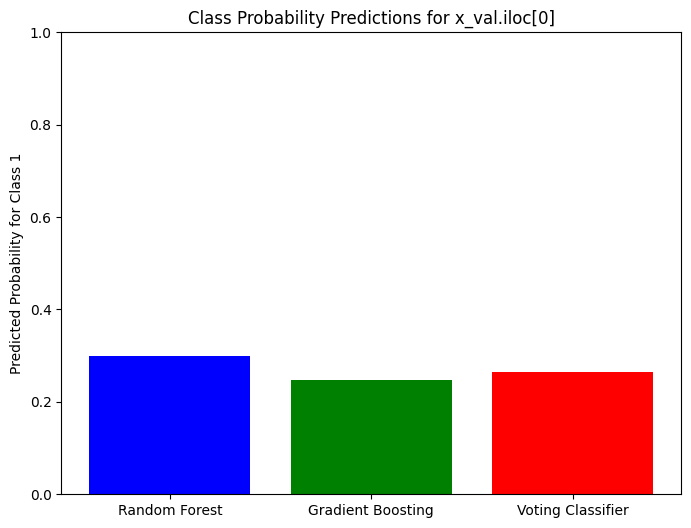

In [21]:
# Extract the first sample as a DataFrame
sample = x_val.iloc[[0]]

# Compute class probabilities for rf_saved
rf_prob = rf_saved.predict_proba(sample)[:, 1][0]

# Compute class probabilities for gb_saved
gb_prob = gb_saved.predict_proba(sample)[:, 1][0]

# Compute class probabilities for vc_saved
vc_prob = vc_saved.predict_proba(sample)[:, 1][0]

# Plot the class probabilities
probs = [rf_prob, gb_prob, vc_prob]
labels = ['Random Forest', 'Gradient Boosting', 'Voting Classifier']

plt.figure(figsize=(8, 6))
plt.bar(labels, probs, color=['blue', 'green', 'red'])
plt.ylabel('Predicted Probability for Class 1')
plt.title('Class Probability Predictions for x_val.iloc[0]')
plt.ylim(0, 1)
plt.show()